## IMPORT LIBRARIES

In [1]:
import numpy as np
import pandas as pd
import os
import cv2
import matplotlib.pyplot as plt

from tensorflow.keras.utils import to_categorical
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Conv2D, MaxPooling2D, Flatten, Dropout, BatchNormalization
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping

## LOAD DATASET

In [2]:
train_path = "../data/emnist-letters-train.csv"
test_path = "../data/emnist-letters-test.csv"

train_df = pd.read_csv(train_path)
test_df = pd.read_csv(test_path)

print("Train Shape:", train_df.shape)
print("Test Shape:", test_df.shape)

Train Shape: (88799, 785)
Test Shape: (14799, 785)


## SPLIT FEATURES & LABELS

In [3]:
X_train = train_df.iloc[:, 1:].values
y_train = train_df.iloc[:, 0].values - 1

X_test = test_df.iloc[:, 1:].values
y_test = test_df.iloc[:, 0].values - 1

## NORMALIZE DATA

In [4]:
X_train = X_train / 255.0
X_test = X_test / 255.0

## RESHAPE IMAGES

In [5]:
X_train = X_train.reshape(-1, 28, 28, 1)
X_test = X_test.reshape(-1, 28, 28, 1)

print("New Shape:", X_train.shape)

New Shape: (88799, 28, 28, 1)


## ONE HOT ENCODING

In [6]:
y_train = to_categorical(y_train, num_classes=26)
y_test = to_categorical(y_test, num_classes=26)

## DATA AUGMENTATION

In [7]:
datagen = ImageDataGenerator(
    rotation_range=10,
    zoom_range=0.1,
    width_shift_range=0.1,
    height_shift_range=0.1
)

datagen.fit(X_train)

## CNN MODEL

In [8]:
model = Sequential()

model.add(Conv2D(32, (3,3), activation='relu', input_shape=(28,28,1)))
model.add(BatchNormalization())
model.add(Conv2D(32, (3,3), activation='relu'))
model.add(BatchNormalization())
model.add(MaxPooling2D(2,2))
model.add(Dropout(0.25))

model.add(Conv2D(64, (3,3), activation='relu'))
model.add(BatchNormalization())
model.add(Conv2D(64, (3,3), activation='relu'))
model.add(BatchNormalization())
model.add(MaxPooling2D(2,2))
model.add(Dropout(0.25))

model.add(Conv2D(128, (3,3), activation='relu'))
model.add(BatchNormalization())
model.add(MaxPooling2D(2,2))
model.add(Dropout(0.3))

model.add(Flatten())

model.add(Dense(256, activation='relu'))
model.add(Dropout(0.5))

model.add(Dense(26, activation='softmax'))

c:\Users\f\AppData\Local\Programs\Python\Python310\lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


## COMPILE MODEL

In [9]:
model.compile(
    optimizer=Adam(learning_rate=0.0005),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 26, 26, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 24, 24, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 24, 24, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 12, 12, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 12, 12, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 10, 10, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 10, 10, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 8, 8, 64)       │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 8, 8, 64)       │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 4, 4, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 4, 4, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 2, 2, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 2, 2, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 1, 1, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 1, 1, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 26)             │         6,682 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 179,834 (702.48 KB)

 Trainable params: 179,194 (699.98 KB)

 Non-trainable params: 640 (2.50 KB)

## EARLY STOPPING

In [10]:
early_stop = EarlyStopping(
    monitor='val_accuracy',
    patience=3,
    restore_best_weights=True,
    verbose=1
)

## TRAIN MODEL

In [11]:
history = model.fit(
    X_train, y_train,
    epochs=20,
    batch_size=128,
    validation_data=(X_test, y_test),
    callbacks=[early_stop]
)

Epoch 1/20
694/694 ━━━━━━━━━━━━━━━━━━━━ 264s 328ms/step - accuracy: 0.6102 - loss: 1.3108 - val_accuracy: 0.8609 - val_loss: 0.4214
Epoch 2/20
694/694 ━━━━━━━━━━━━━━━━━━━━ 257s 327ms/step - accuracy: 0.8464 - loss: 0.4816 - val_accuracy: 0.9079 - val_loss: 0.2599
Epoch 3/20
694/694 ━━━━━━━━━━━━━━━━━━━━ 220s 317ms/step - accuracy: 0.8815 - loss: 0.3635 - val_accuracy: 0.9159 - val_loss: 0.2404
Epoch 4/20
694/694 ━━━━━━━━━━━━━━━━━━━━ 221s 318ms/step - accuracy: 0.8992 - loss: 0.3113 - val_accuracy: 0.9245 - val_loss: 0.2218
Epoch 5/20
694/694 ━━━━━━━━━━━━━━━━━━━━ 221s 319ms/step - accuracy: 0.9083 - loss: 0.2788 - val_accuracy: 0.9274 - val_loss: 0.2081
Epoch 6/20
694/694 ━━━━━━━━━━━━━━━━━━━━ 223s 321ms/step - accuracy: 0.9160 - loss: 0.2541 - val_accuracy: 0.9281 - val_loss: 0.2081
Epoch 7/20
694/694 ━━━━━━━━━━━━━━━━━━━━ 222s 320ms/step - accuracy: 0.9192 - loss: 0.2417 - val_accuracy: 0.9262 - val_loss: 0.2075
Epoch 8/20
694/694 ━━━━━━━━━━━━━━━━━━━━ 226s 325ms/step - accuracy: 0.9234 -

## EVALUATE MODEL

In [12]:
loss, acc = model.evaluate(X_test, y_test)
print("Test Accuracy:", acc)

463/463 ━━━━━━━━━━━━━━━━━━━━ 10s 21ms/step - accuracy: 0.9403 - loss: 0.1787
Test Accuracy: 0.9402662515640259


## SAVE MODEL

In [13]:
os.makedirs("../models", exist_ok=True)

model.save("../models/alphabet_model.h5")

print("Model Saved Successfully!")

Model Saved Successfully!


## ACCURACY GRAPH

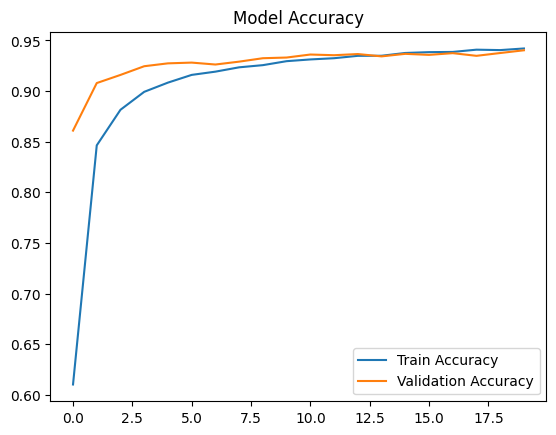

In [14]:
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')

plt.legend()
plt.title("Model Accuracy")
plt.show()

## CONFUSION MATRIX

463/463 ━━━━━━━━━━━━━━━━━━━━ 10s 20ms/step


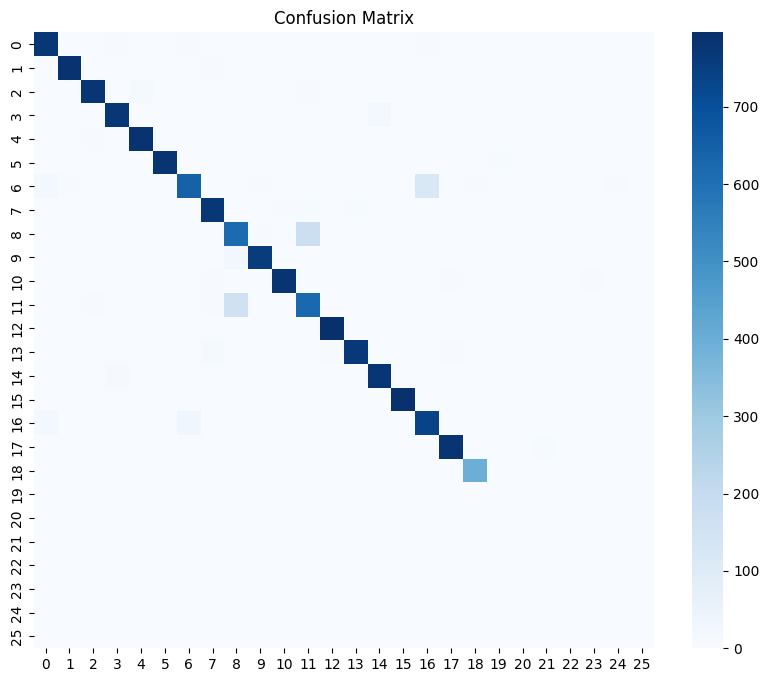

In [15]:
import seaborn as sns
from sklearn.metrics import confusion_matrix
import numpy as np

y_pred = model.predict(X_test)
y_pred_classes = np.argmax(y_pred, axis=1)
y_true = np.argmax(y_test, axis=1)

cm = confusion_matrix(y_true, y_pred_classes)

plt.figure(figsize=(10,8))
sns.heatmap(cm, cmap='Blues')
plt.title("Confusion Matrix")
plt.show()

## SAVE TEST IMAGES

In [16]:
df = pd.read_csv("../data/emnist-letters-test.csv")

os.makedirs("test_images", exist_ok=True)

alphabet = "ABCDEFGHIJKLMNOPQRSTUVWXYZ"

for i in range(20):
    label = df.iloc[i, 0] - 1
    image = df.iloc[i, 1:].values.reshape(28, 28)

    image = np.rot90(image)
    image = np.fliplr(image)

    image = image.astype("uint8")

    filename = f"test_images/{alphabet[label]}_{i}.png"
    cv2.imwrite(filename, image)

print("Images saved correctly!")

Images saved correctly!
